In [1]:
from pathlib import Path

import torch

from rtnls_inference import (
    HeatmapRegressionEnsemble,
    SegmentationEnsemble,
)

/home/jose/.pyenv/versions/rtnls/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


## Segmentation of preprocessed images

Here we segment images preprocessed using 0_preprocess.ipynb


In [2]:
ds_path = Path("../samples/fundus")

# input folders. these are the folders where we stored the preprocessed images
rgb_path = ds_path / "rgb"
ce_path = ds_path / "ce"

# these are the output folders for:
av_path = ds_path / "av"  # artery-vein segmentations
vessels_path = ds_path / "vessels"  # vessels segmentation
discs_path = ds_path / "discs"  # optic disc segmentations
overlays_path = ds_path / "overlays"  # optional overlay visualizations

device = torch.device("cuda:0")  # device to use for inference

In [3]:
rgb_paths = sorted(list(rgb_path.glob("*.png")))
ce_paths = sorted(list(ce_path.glob("*.png")))

In [4]:
data = [{
    'id': Path(rgb_path).stem,
    'image': rgb_path,
    'contrast_enhanced': ce_path
} for rgb_path, ce_path in zip(rgb_paths, ce_paths)]

In [5]:
data

[{'id': 'CHASEDB1_08L',
  'image': PosixPath('../samples/fundus/rgb/CHASEDB1_08L.png'),
  'contrast_enhanced': PosixPath('../samples/fundus/ce/CHASEDB1_08L.png')},
 {'id': 'CHASEDB1_12R',
  'image': PosixPath('../samples/fundus/rgb/CHASEDB1_12R.png'),
  'contrast_enhanced': PosixPath('../samples/fundus/ce/CHASEDB1_12R.png')},
 {'id': 'DRIVE_22',
  'image': PosixPath('../samples/fundus/rgb/DRIVE_22.png'),
  'contrast_enhanced': PosixPath('../samples/fundus/ce/DRIVE_22.png')},
 {'id': 'DRIVE_40',
  'image': PosixPath('../samples/fundus/rgb/DRIVE_40.png'),
  'contrast_enhanced': PosixPath('../samples/fundus/ce/DRIVE_40.png')},
 {'id': 'HRF_04_g',
  'image': PosixPath('../samples/fundus/rgb/HRF_04_g.png'),
  'contrast_enhanced': PosixPath('../samples/fundus/ce/HRF_04_g.png')},
 {'id': 'HRF_07_dr',
  'image': PosixPath('../samples/fundus/rgb/HRF_07_dr.png'),
  'contrast_enhanced': PosixPath('../samples/fundus/ce/HRF_07_dr.png')}]

### Artery-vein segmentation


In [6]:
av_ensemble = SegmentationEnsemble.from_huggingface("Eyened/vascx:artery_vein/av_july24.pt").to(device)
av_ensemble.predict_preprocessed(data, dest_path=av_path, num_workers=2)

  0%|          | 0/1 [00:00<?, ?it/s]/home/jose/.pyenv/versions/rtnls/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/jose/.pyenv/versions/rtnls/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered in

## Vessel segmentation (optional)

In [7]:
vessels_ensemble = SegmentationEnsemble.from_huggingface("Eyened/vascx:vessels/vessels_july24.pt").to(device)
vessels_ensemble.predict_preprocessed(data, dest_path=vessels_path, num_workers=2)

100%|██████████| 1/1 [00:02<00:00,  2.43s/it]


### Disc segmentation


In [8]:
disc_ensemble = SegmentationEnsemble.from_huggingface("Eyened/vascx:disc/disc_july24.pt").to(device)
disc_ensemble.predict_preprocessed(data, dest_path=discs_path, num_workers=2)

100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


### Fovea detection


In [9]:
fovea_ensemble = HeatmapRegressionEnsemble.from_huggingface("Eyened/vascx:fovea/fovea_july24.pt").to(device)
# note: this model does not use contrast enhanced images
df = fovea_ensemble.predict_preprocessed(data, num_workers=2)
df.columns = ["mean_x", "mean_y"]
df.to_csv(ds_path / "fovea.csv")

  0%|          | 0/1 [00:00<?, ?it/s]/home/jose/.pyenv/versions/rtnls/lib/python3.12/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


In [10]:
df

,mean_x,mean_y
CHASEDB1_08L,953.400024,553.799988
CHASEDB1_12R,101.800003,634.200012
DRIVE_22,487.000000,522.599976
DRIVE_40,503.399994,521.000000
HRF_04_g,552.599976,533.799988
HRF_07_dr,545.000000,534.599976


### Plotting the retinas (optional)

This will only work if you ran all the models and stored the outputs using the same folder/file names as above


In [11]:
from vascx.fundus.loader import RetinaLoader

from rtnls_enface.utils.plotting import plot_gridfns

loader = RetinaLoader.from_folder(ds_path)

Folder av_path: 6 files
Folder disc_path: 6 files
Folder fundus_path: 6 files
Folder vessels_path: 6 files


<Axes: >

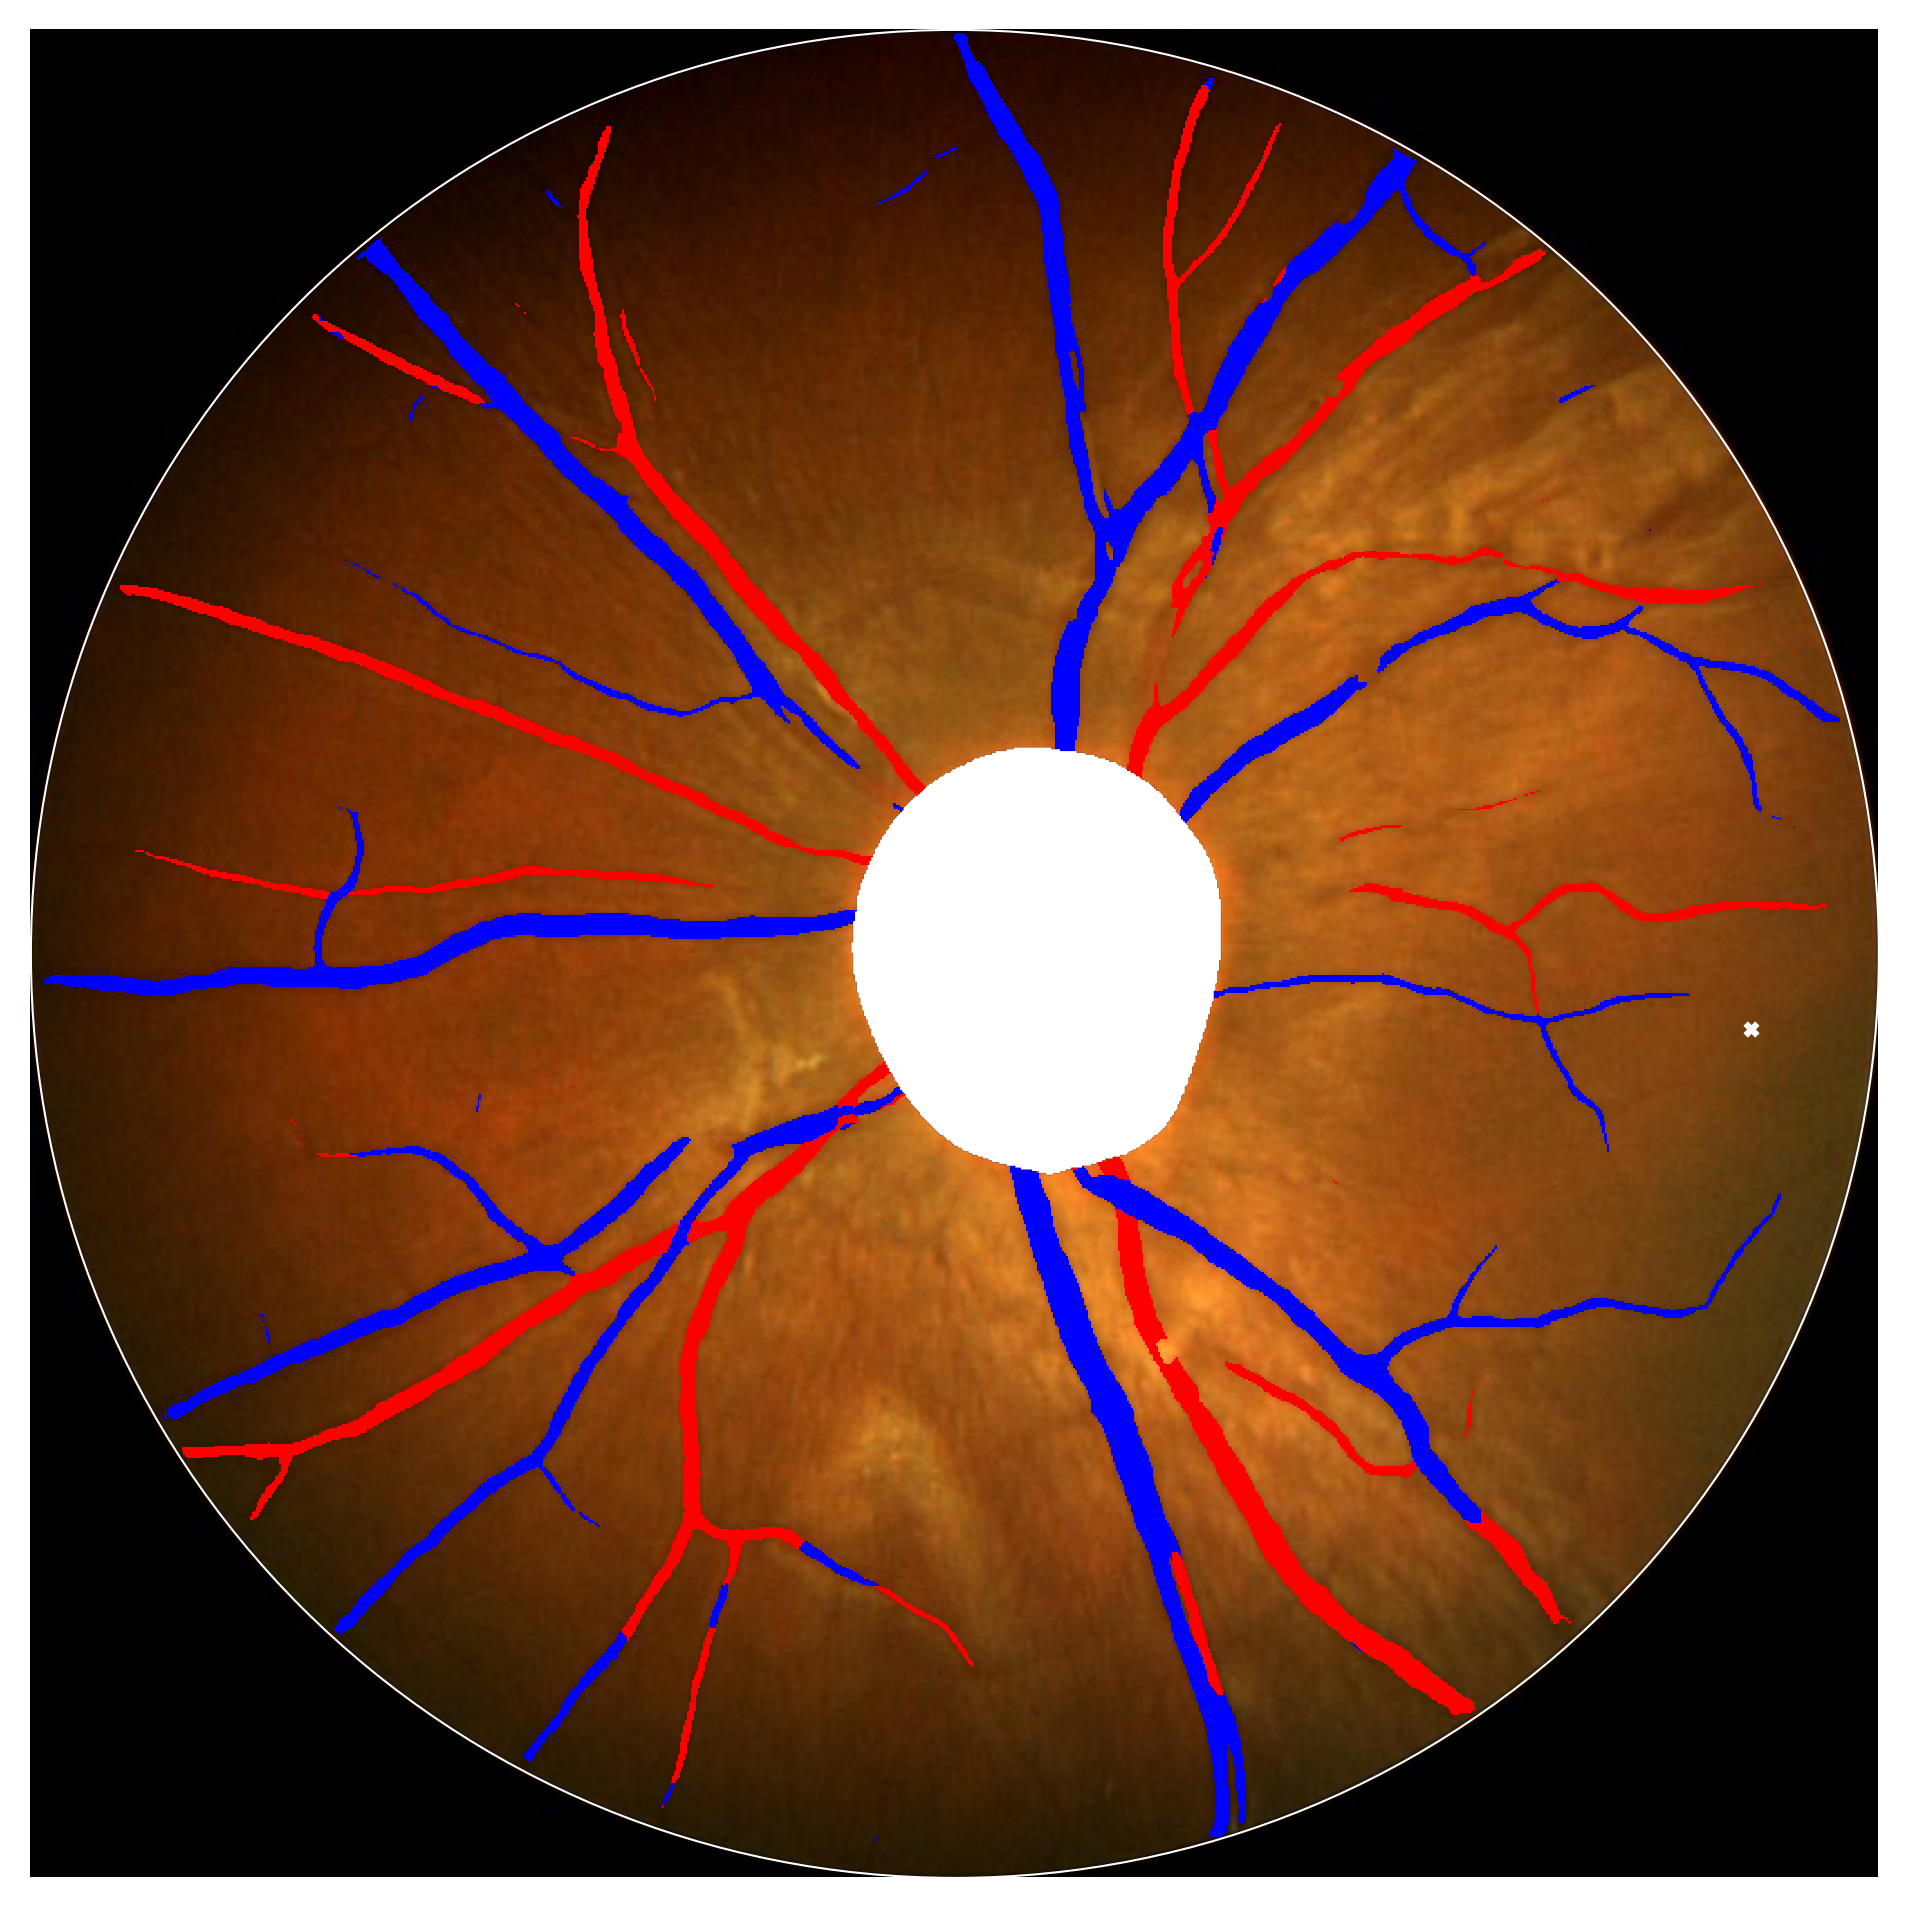

In [12]:
loader[0].plot(av=True, disc=True, fovea=True, bounds=True)

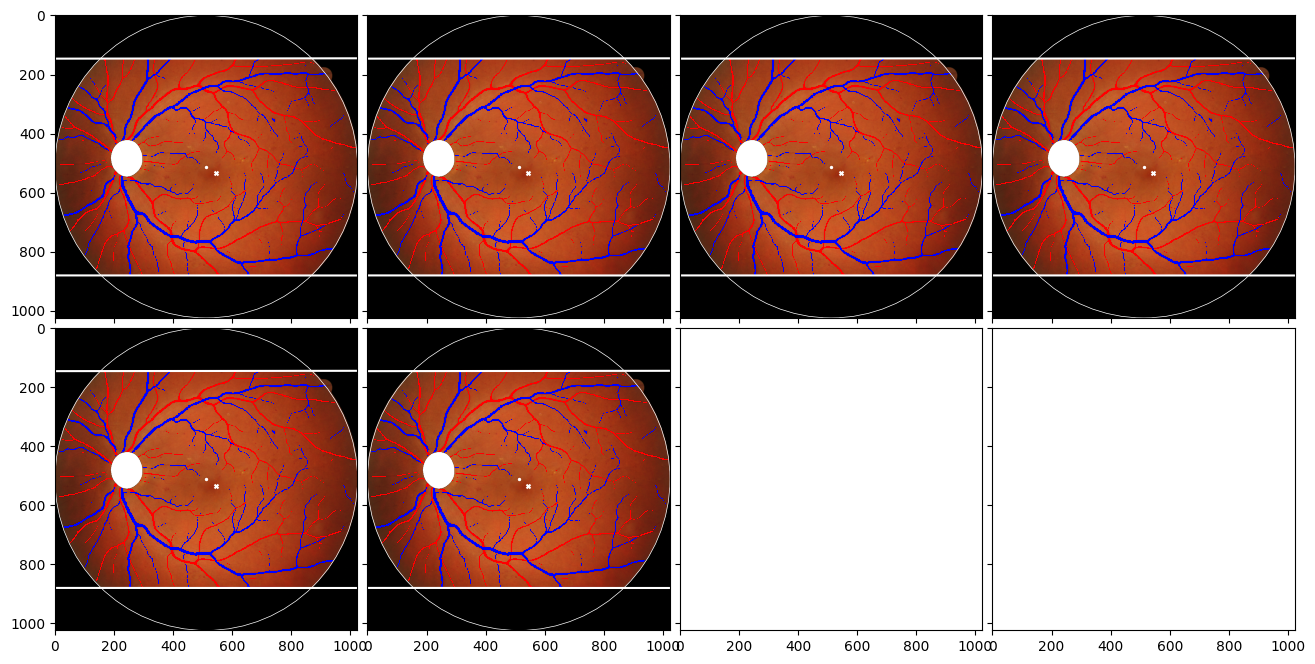

In [13]:
plot_gridfns([lambda ax: ret.plot(av=True, disc=True, fovea=True, bounds=True, ax=ax) for ret in loader])

### Storing visualizations (optional)


In [14]:
from matplotlib import pyplot as plt
if not overlays_path.exists():
    overlays_path.mkdir()
for ret in loader:
    fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=150)
    ret.plot(av=True, disc=True, fovea=True, bounds=True, ax=ax)
    fig.savefig(overlays_path / f"{ret.id}.png", bbox_inches="tight", pad_inches=0)
    plt.close(fig)